In [1]:
!pip install kaggle
!pip install git+https://github.com/openai/CLIP.git
!pip install torch torchvision

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-02pm6cg9
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-02pm6cg9
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=001619752c9961e9f4c1a14fb14d0f79334f88ac916047ee45aba76ccbfec5ae
  Stored in directory: /tmp/pip-ephem-wheel-cache-4q_xfug3/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nichalhaas","key":"a5ccd9be2dd12e0a44a33757b23304c4"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import torch
print(torch.cuda.is_available())

True


In [5]:
!kaggle datasets download -d wenewone/cub2002011

# ===============================
# 5️⃣ Unzip Dataset
# ===============================
!unzip -q cub2002011.zip

# ===============================
# 6️⃣ Verify Structure
# ===============================
print("\n📂 Root Directory:")
!ls

print("\n📂 Inside CUB_200_2011:")
!ls CUB_200_2011

Dataset URL: https://www.kaggle.com/datasets/wenewone/cub2002011
License(s): CC0-1.0
100% 1.49G/1.49G [00:48<00:00, 33.2MB/s]


📂 Root Directory:
best_model.pth	cub2002011.zip	sample_data
CUB_200_2011	cvpr2016_cub	segmentations

📂 Inside CUB_200_2011:
attributes	    image_class_labels.txt  parts
bounding_boxes.txt  images		    README
classes.txt	    images.txt		    train_test_split.txt


In [6]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

dataset_path = "CUB_200_2011"
images_path = os.path.join(dataset_path, "images")

# load metadata
images = pd.read_csv(
    os.path.join(dataset_path, "images.txt"),
    sep=" ",
    names=["img_id","filepath"]
)

bbox = pd.read_csv(
    os.path.join(dataset_path, "bounding_boxes.txt"),
    sep=" ",
    names=["img_id","x","y","width","height"]
)

split = pd.read_csv(
    os.path.join(dataset_path, "train_test_split.txt"),
    sep=" ",
    names=["img_id","is_train"]
)

# merge all tables
data = images.merge(bbox,on="img_id").merge(split,on="img_id")

train_out = "CUB_cropped/train"
test_out = "CUB_cropped/test"

os.makedirs(train_out, exist_ok=True)
os.makedirs(test_out, exist_ok=True)

print("Cropping images...")

for _, row in tqdm(data.iterrows(), total=len(data)):

    img_path = os.path.join(images_path, row.filepath)

    img = Image.open(img_path).convert("RGB")

    x = int(row.x)
    y = int(row.y)
    w = int(row.width)
    h = int(row.height)

    crop = img.crop((x, y, x+w, y+h))

    if row.is_train == 1:
        save_dir = train_out
    else:
        save_dir = test_out

    save_path = os.path.join(save_dir, row.filepath)

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    crop.save(save_path)

print("Cropping completed")

Cropping images...


100%|██████████| 11788/11788 [00:50<00:00, 234.15it/s]

Cropping completed


In [ ]:
torch.cuda.empty_cache()

In [ ]:
# =====================================
# FINAL STABLE SWIN + PART MODEL
# =====================================

!pip install timm

import torch
import torch.nn as nn
import timm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.amp as amp
from timm.data.mixup import Mixup
from timm.loss import SoftTargetCrossEntropy
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True


# =====================================
# CONFIG
# =====================================

class CFG:
    model_name = "swin_large_patch4_window12_384"
    num_classes = 200
    num_parts = 4
    image_size = 384

    stage1_epochs = 8
    stage2_epochs = 42

    batch_size = 16
    num_workers = 4

    backbone_lr = 5e-6
    head_lr = 2e-4
    weight_decay = 0.05

    mixup_alpha = 0.8
    cutmix_alpha = 1.0
    label_smoothing = 0.1

    train_dir = "CUB_cropped/train"
    test_dir = "CUB_cropped/test"

    save_path = "best_model.pth"

cfg = CFG()


# =====================================
# PART ATTENTION
# =====================================

class CrossAttentionPart(nn.Module):

    def __init__(self, dim, num_parts=4):
        super().__init__()
        self.part_tokens = nn.Parameter(torch.randn(1, num_parts, dim))
        self.attn = nn.MultiheadAttention(dim, num_heads=8, batch_first=True)

    def forward(self, tokens):
        B = tokens.size(0)
        queries = self.part_tokens.expand(B, -1, -1)
        part_feats, _ = self.attn(queries, tokens, tokens)
        return part_feats


# =====================================
# MODEL
# =====================================

class SwinPartModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            cfg.model_name,
            pretrained=True,
            num_classes=0,
            global_pool=""
        )

        dim = self.backbone.num_features

        self.part_module = CrossAttentionPart(dim, cfg.num_parts)

        self.fusion = nn.Sequential(
            nn.LayerNorm(dim * (1 + cfg.num_parts)),
            nn.Linear(dim * (1 + cfg.num_parts), dim),
            nn.GELU(),
            nn.Dropout(0.4)
        )

        self.classifier = nn.Linear(dim, cfg.num_classes)

    def forward(self, x):

        tokens = self.backbone.forward_features(x)

        if tokens.dim() == 4:
            B, H, W, C = tokens.shape
            tokens = tokens.view(B, H * W, C)

        global_feat = tokens.mean(dim=1)

        part_feats = self.part_module(tokens)
        part_flat = part_feats.reshape(part_feats.size(0), -1)

        fused = torch.cat([global_feat, part_flat], dim=1)
        fused = self.fusion(fused)

        logits = self.classifier(fused)

        return logits, part_feats  # safe now (no compile)


model = SwinPartModel().to(device)


# =====================================
# TRANSFORMS
# =====================================

mean=[0.485,0.456,0.406]
std=[0.229,0.224,0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(cfg.image_size, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean,std),
    transforms.RandomErasing(p=0.3)
])

test_tf = transforms.Compose([
    transforms.Resize(int(cfg.image_size*1.15)),
    transforms.CenterCrop(cfg.image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])


# =====================================
# DATA
# =====================================

train_dataset = ImageFolder(cfg.train_dir, transform=train_tf)
test_dataset  = ImageFolder(cfg.test_dir, transform=test_tf)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True
)


# =====================================
# MIXUP
# =====================================

mixup_fn = Mixup(
    mixup_alpha=cfg.mixup_alpha,
    cutmix_alpha=cfg.cutmix_alpha,
    prob=1.0,
    switch_prob=0.5,
    label_smoothing=cfg.label_smoothing,
    num_classes=cfg.num_classes
)

criterion = SoftTargetCrossEntropy()


# =====================================
# OPTIMIZER
# =====================================

backbone_params=[]
head_params=[]

for name,p in model.named_parameters():
    if "backbone" in name:
        backbone_params.append(p)
    else:
        head_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params":backbone_params,"lr":cfg.backbone_lr},
        {"params":head_params,"lr":cfg.head_lr}
    ],
    weight_decay=cfg.weight_decay
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=cfg.stage1_epochs + cfg.stage2_epochs,
    eta_min=1e-6
)

scaler = amp.GradScaler()


# =====================================
# DIVERSITY LOSS
# =====================================

def diversity_loss(parts):
    B, P, C = parts.shape
    parts = nn.functional.normalize(parts, dim=-1)
    sim = torch.matmul(parts, parts.transpose(1,2))
    loss = (sim.sum() - B * P) / (B * P * (P-1))
    return loss


# =====================================
# EVALUATION
# =====================================

@torch.no_grad()
def evaluate(model, loader):

    model.eval()
    correct=0
    total=0

    for imgs,labels in loader:

        imgs=imgs.to(device)
        labels=labels.to(device)

        with amp.autocast(device_type="cuda"):
            out1,_ = model(imgs)
            out2,_ = model(torch.flip(imgs,[3]))

        outputs=(out1+out2)/2
        _,pred=outputs.max(1)

        correct+=(pred==labels).sum().item()
        total+=labels.size(0)

    return 100*correct/total


# =====================================
# TRAIN LOOP
# =====================================

best_acc=0
patience=6
no_improve=0

total_epochs = cfg.stage1_epochs + cfg.stage2_epochs

for epoch in range(total_epochs):

    model.train()
    running_loss=0

    for imgs,labels in tqdm(train_loader):

        imgs=imgs.to(device)
        labels=labels.to(device)

        imgs,labels=mixup_fn(imgs,labels)

        optimizer.zero_grad()

        with amp.autocast(device_type="cuda"):
            logits, parts = model(imgs)
            cls_loss = criterion(logits,labels)
            div_loss = diversity_loss(parts)
            loss = cls_loss + 0.05 * div_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss+=loss.item()

    scheduler.step()

    # evaluate every 2 epochs
    if (epoch+1)%2==0:
        val_acc = evaluate(model,test_loader)

        print(f"Epoch {epoch+1} | Acc {val_acc:.2f}")

        if val_acc>best_acc:
            best_acc=val_acc
            no_improve=0
            torch.save(model.state_dict(),cfg.save_path)
        else:
            no_improve+=1

        if no_improve>=patience:
            print("Early stopping")
            break

print("Best Accuracy:",best_acc)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/801M [00:00<?, ?B/s]

100%|██████████| 375/375 [01:22<00:00,  4.54it/s]


Epoch 2 | Acc 80.12


100%|██████████| 375/375 [01:22<00:00,  4.54it/s]


...

Epoch 46 | Acc 89.39


100%|██████████| 375/375 [01:22<00:00,  4.54it/s]


Epoch 48 | Acc 89.28


100%|██████████| 375/375 [01:22<00:00,  4.54it/s]


Epoch 50 | Acc 89.28
Best Accuracy: 89.38557128063513


In [9]:
# =====================================
# FINAL SAFE TTA (SWIN 384 COMPATIBLE)
# =====================================

import torch
import torch.nn as nn
import timm
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.amp as amp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =====================================
# MODEL (same as training)
# =====================================

class CrossAttentionPart(nn.Module):
    def __init__(self, dim, num_parts=4):
        super().__init__()
        self.part_tokens = nn.Parameter(torch.randn(1, num_parts, dim))
        self.attn = nn.MultiheadAttention(dim, num_heads=8, batch_first=True)

    def forward(self, tokens):
        B = tokens.size(0)
        queries = self.part_tokens.expand(B, -1, -1)
        part_feats, _ = self.attn(queries, tokens, tokens)
        return part_feats


class SwinPartModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "swin_large_patch4_window12_384",
            pretrained=False,
            num_classes=0,
            global_pool=""
        )

        dim = self.backbone.num_features

        self.part_module = CrossAttentionPart(dim, 4)

        self.fusion = nn.Sequential(
            nn.LayerNorm(dim * 5),
            nn.Linear(dim * 5, dim),
            nn.GELU(),
            nn.Dropout(0.4)
        )

        self.classifier = nn.Linear(dim, 200)

    def forward(self, x):

        tokens = self.backbone.forward_features(x)

        if tokens.dim() == 4:
            B, H, W, C = tokens.shape
            tokens = tokens.view(B, H * W, C)

        global_feat = tokens.mean(dim=1)
        part_feats = self.part_module(tokens)
        part_flat = part_feats.reshape(part_feats.size(0), -1)

        fused = torch.cat([global_feat, part_flat], dim=1)
        fused = self.fusion(fused)

        return self.classifier(fused)


# =====================================
# LOAD MODEL
# =====================================

model = SwinPartModel().to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

print("✅ Model Loaded")


# =====================================
# TRANSFORM (CRITICAL FIX)
# =====================================

test_tf = transforms.Compose([
    transforms.Resize(384),         # keep ratio
    transforms.CenterCrop(384),     # FORCE EXACT SIZE
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


# =====================================
# DATA
# =====================================

test_dataset = ImageFolder("CUB_cropped/test", transform=test_tf)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# =====================================
# SAFE TTA (NO SIZE ERRORS)
# =====================================

@torch.no_grad()
def evaluate_tta(model, loader):

    correct = 0
    total = 0

    for imgs, labels in tqdm(loader):

        imgs = imgs.to(device)
        labels = labels.to(device)

        with amp.autocast(device_type="cuda"):

            # 1️⃣ Original
            out1 = model(imgs)

            # 2️⃣ Horizontal Flip
            out2 = model(torch.flip(imgs, dims=[3]))

            # 3️⃣ Slight Shift (still 384 safe)
            out3 = model(torch.roll(imgs, shifts=5, dims=2))

        outputs = (out1 + out2 + out3) / 3

        _, preds = outputs.max(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return 100 * correct / total


# =====================================
# RUN
# =====================================

acc = evaluate_tta(model, test_loader)

print(f"\n🔥 FINAL TTA ACCURACY: {acc:.2f}%")

✅ Model Loaded


100%|██████████| 363/363 [09:38<00:00,  1.59s/it]


🔥 FINAL TTA ACCURACY: 90.35%


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder

# -------------------------------------
# CLEAN TRANSFORM (NO AUGMENTATION)
# -------------------------------------
clean_tf = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# -------------------------------------
# LOAD DATASET
# -------------------------------------
clean_test_dataset = ImageFolder(
    "CUB_cropped/test",
    transform=clean_tf
)

print("✅ Dataset Loaded:", len(clean_test_dataset))

✅ Dataset Loaded: 5794


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


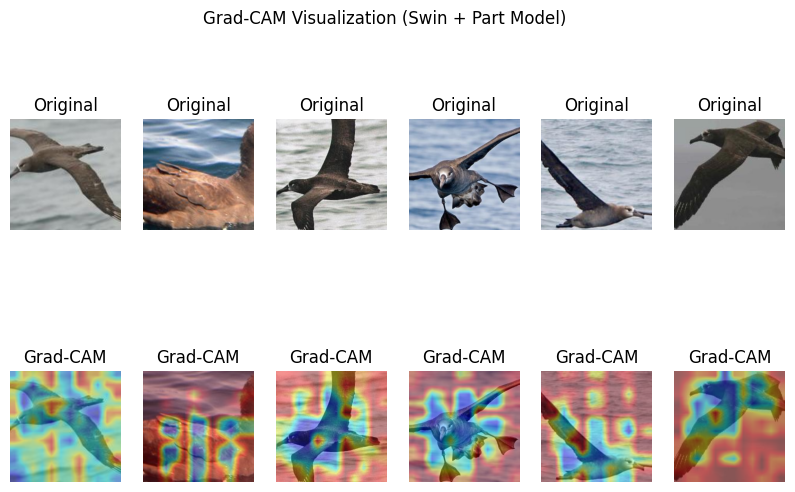

In [ ]:
# =====================================
# 🔥 GRAD-CAM FOR SWIN PART MODEL
# =====================================

import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =====================================
# 🔹 DENORMALIZE
# =====================================
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    return img.clamp(0,1)


# =====================================
# 🔹 HOOKS FOR FEATURE + GRAD
# =====================================

features = []
gradients = []

def forward_hook(module, input, output):
    features.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])


# =====================================
# 🔥 TARGET LAYER (IMPORTANT)
# =====================================

# last Swin stage
target_layer = model.backbone.layers[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)


# =====================================
# 🔥 GRAD-CAM FUNCTION
# =====================================

def gradcam(img):

    model.eval()
    features.clear()
    gradients.clear()

    x = img.unsqueeze(0).to(device)
    x.requires_grad = True

    output = model(x)

    # handle if model returns tuple
    if isinstance(output, tuple):
        output = output[0]

    pred_class = output.argmax(1)

    loss = output[0, pred_class]
    loss.backward()

    # get stored values
    fmap = features[0]       # [B, H, W, C]
    grad = gradients[0]      # same shape

    fmap = fmap[0].detach().cpu().numpy()
    grad = grad[0].detach().cpu().numpy()

    # global average pooling of gradients
    weights = np.mean(grad, axis=(0,1))

    cam = np.zeros(fmap.shape[:2], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * fmap[:,:,i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (384,384))
    cam = (cam - cam.min()) / (cam.max() - cam.min())

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)

    img_vis = denormalize(img).permute(1,2,0).cpu().numpy()

    overlay = 0.6*img_vis + 0.4*(heatmap/255)

    return img_vis, overlay


# =====================================
# 🔥 VISUALIZE MULTIPLE IMAGES
# =====================================

plt.figure(figsize=(10,6))

for i in range(6):
    img, _ = clean_test_dataset[i]

    original, cam = gradcam(img)

    plt.subplot(2,6,i+1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,6,i+7)
    plt.imshow(cam)
    plt.title("Grad-CAM")
    plt.axis("off")

plt.suptitle("Grad-CAM Visualization (Swin + Part Model)")
plt.show()

In [ ]:
clean_tf = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [ ]:
clean_dataset = ImageFolder("CUB_cropped/train", transform=clean_tf)

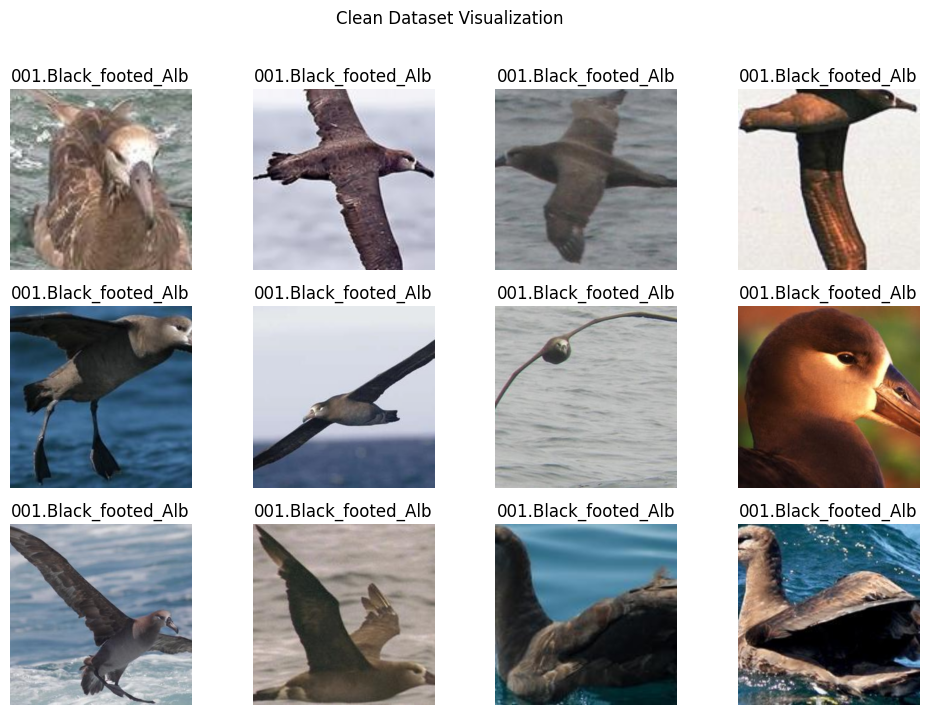

In [ ]:
fig = plt.figure(figsize=(12,8))

for i in range(12):
    img, label = clean_dataset[i]

    img = denormalize(img)

    ax = fig.add_subplot(3,4,i+1)
    ax.imshow(img.permute(1,2,0))
    ax.set_title(clean_dataset.classes[label][:20])
    ax.axis("off")

plt.suptitle("Clean Dataset Visualization")
plt.show()

In [11]:
clean_tf = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

clean_test_dataset = ImageFolder("CUB_cropped/test", transform=clean_tf)

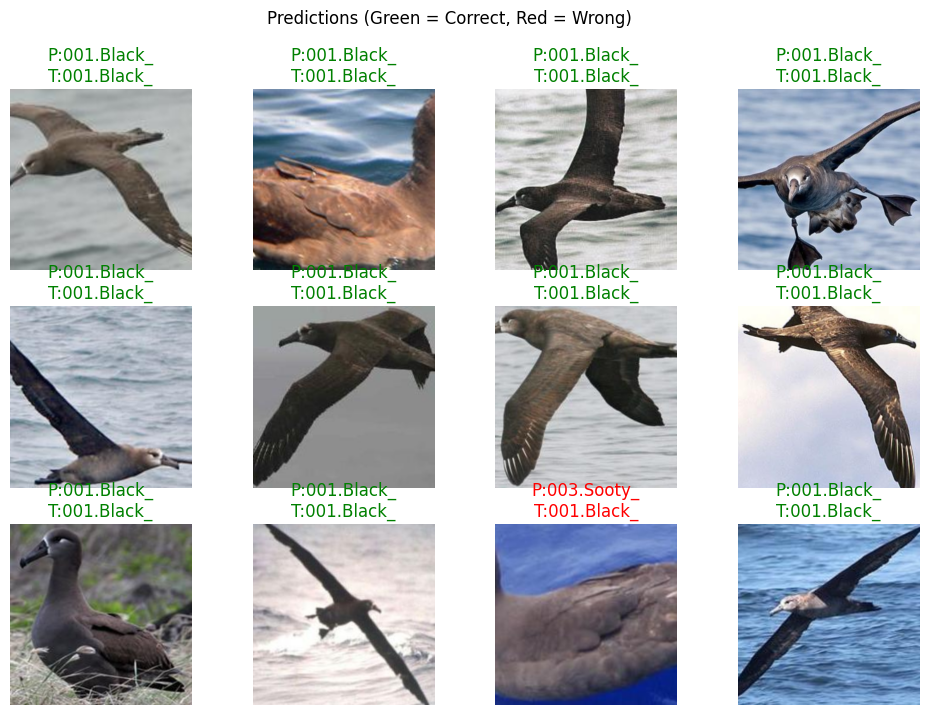

In [ ]:
fig = plt.figure(figsize=(12,8))

count = 0

for i in range(len(clean_test_dataset)):
    img, label = clean_test_dataset[i]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)

    pred = output.argmax(1).item()

    if count < 12:
        img_vis = denormalize(img)

        ax = fig.add_subplot(3,4,count+1)
        ax.imshow(img_vis.permute(1,2,0))

        color = "green" if pred == label else "red"

        ax.set_title(
            f"P:{clean_test_dataset.classes[pred][:10]}\nT:{clean_test_dataset.classes[label][:10]}",
            color=color
        )

        ax.axis("off")

        count += 1

plt.suptitle("Predictions (Green = Correct, Red = Wrong)")
plt.show()

In [12]:
wrong = []

for i in range(len(clean_test_dataset)):
    img, label = clean_test_dataset[i]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)

    pred = output.argmax(1).item()

    if pred != label:
        wrong.append((img, label, pred))

# show hardest errors
fig = plt.figure(figsize=(10,6))

for i in range(6):
    img, label, pred = wrong[i]

    img_vis = denormalize(img)

    ax = fig.add_subplot(2,3,i+1)
    ax.imshow(img_vis.permute(1,2,0))

    ax.set_title(
        f"P:{clean_test_dataset.classes[pred][:10]}\nT:{clean_test_dataset.classes[label][:10]}",
        color="red"
    )

    ax.axis("off")

plt.suptitle("Misclassified Samples (Hard Cases)")
plt.show()

KeyboardInterrupt: 

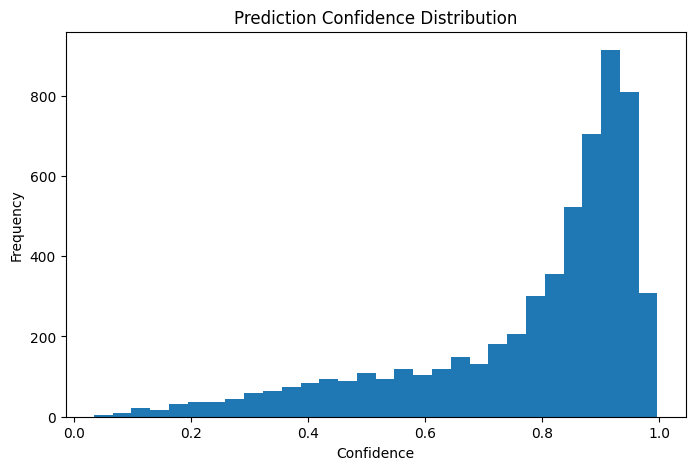

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

confidences = []

model.eval()

for imgs, _ in test_loader:
    imgs = imgs.to(device)

    with torch.no_grad():
        outputs = model(imgs)

    probs = F.softmax(outputs, dim=1)
    max_conf = probs.max(1)[0]

    confidences.extend(max_conf.cpu().numpy())

# plot
plt.figure(figsize=(8,5))
plt.hist(confidences, bins=30)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.show()

In [ ]:
data = []

for i in range(len(clean_test_dataset)):
    img, label = clean_test_dataset[i]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)

    prob = F.softmax(output, dim=1)
    conf, pred = prob.max(1)

    data.append((img, label, pred.item(), conf.item()))

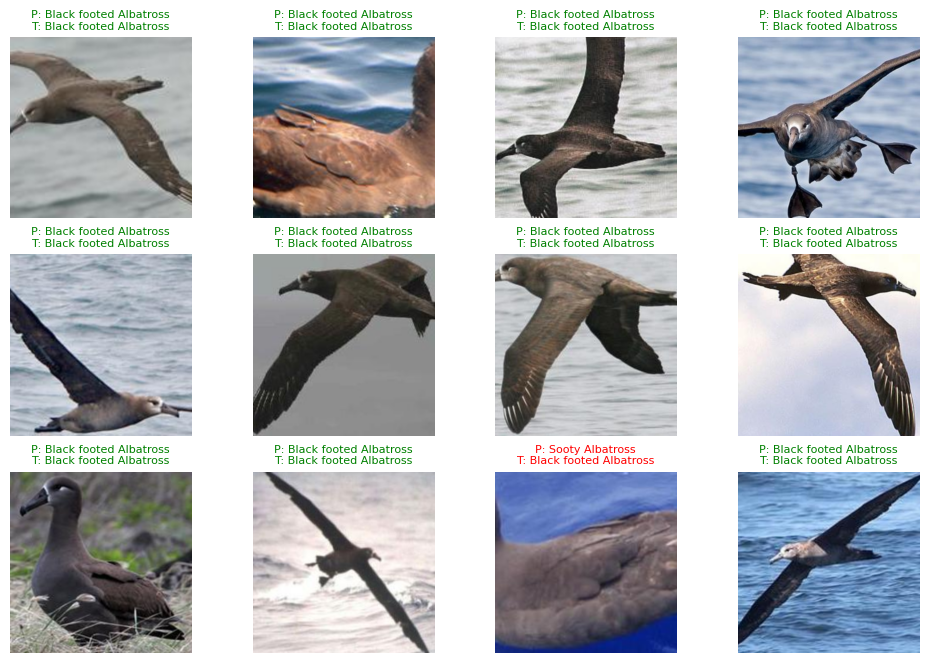

In [ ]:
fig = plt.figure(figsize=(12,8))
def get_class_name(idx):
    name = clean_test_dataset.classes[idx]

    # remove index + clean text
    name = name.split(".")[-1]
    name = name.replace("_", " ")

    return name

for i in range(12):
    img, label = clean_test_dataset[i]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)

    pred = output.argmax(1).item()

    img_vis = denormalize(img)

    ax = fig.add_subplot(3,4,i+1)
    ax.imshow(img_vis.permute(1,2,0))

    pred_name = get_class_name(pred)
    true_name = get_class_name(label)

    color = "green" if pred == label else "red"

    ax.set_title(f"P: {pred_name}\nT: {true_name}", color=color, fontsize=8)
    ax.axis("off")

plt.show()

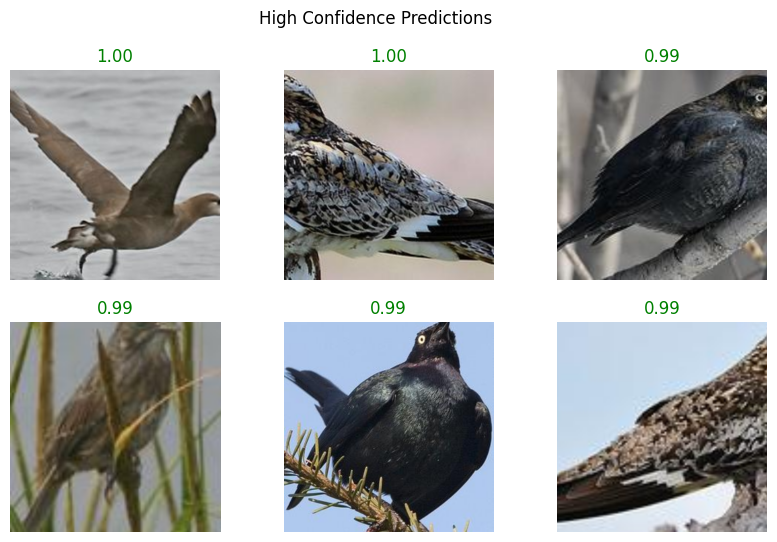

In [ ]:
data_sorted = sorted(data, key=lambda x: x[3], reverse=True)

fig = plt.figure(figsize=(10,6))

for i in range(6):
    img, label, pred, conf = data_sorted[i]

    img_vis = denormalize(img)

    ax = fig.add_subplot(2,3,i+1)
    ax.imshow(img_vis.permute(1,2,0))

    ax.set_title(f"{conf:.2f}", color="green")
    ax.axis("off")

plt.suptitle("High Confidence Predictions")
plt.show()

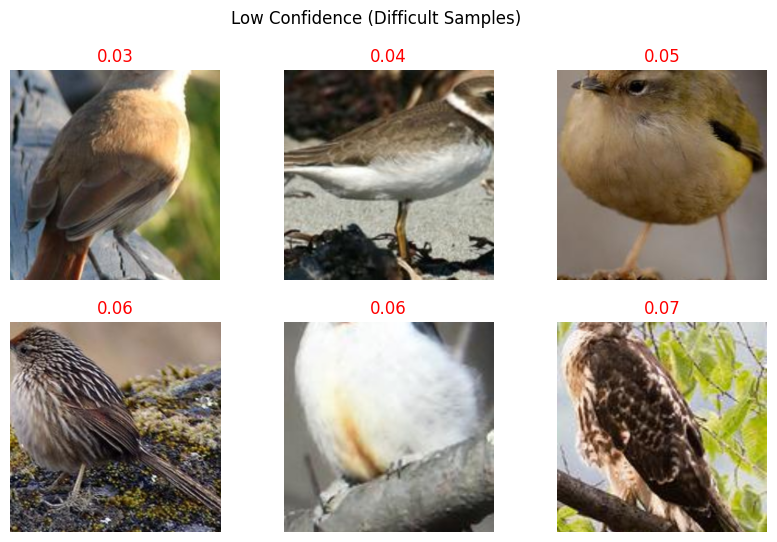

In [ ]:
data_sorted = sorted(data, key=lambda x: x[3])

fig = plt.figure(figsize=(10,6))

for i in range(6):
    img, label, pred, conf = data_sorted[i]

    img_vis = denormalize(img)

    ax = fig.add_subplot(2,3,i+1)
    ax.imshow(img_vis.permute(1,2,0))

    ax.set_title(f"{conf:.2f}", color="red")
    ax.axis("off")

plt.suptitle("Low Confidence (Difficult Samples)")
plt.show()

In [13]:
all_preds = []
all_labels = []

model.eval()

for imgs, labels in test_loader:
    imgs = imgs.to(device)

    with torch.no_grad():
        outputs = model(imgs)

    preds = outputs.argmax(1).cpu().numpy()

    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

print("✅ Predictions collected")

✅ Predictions collected


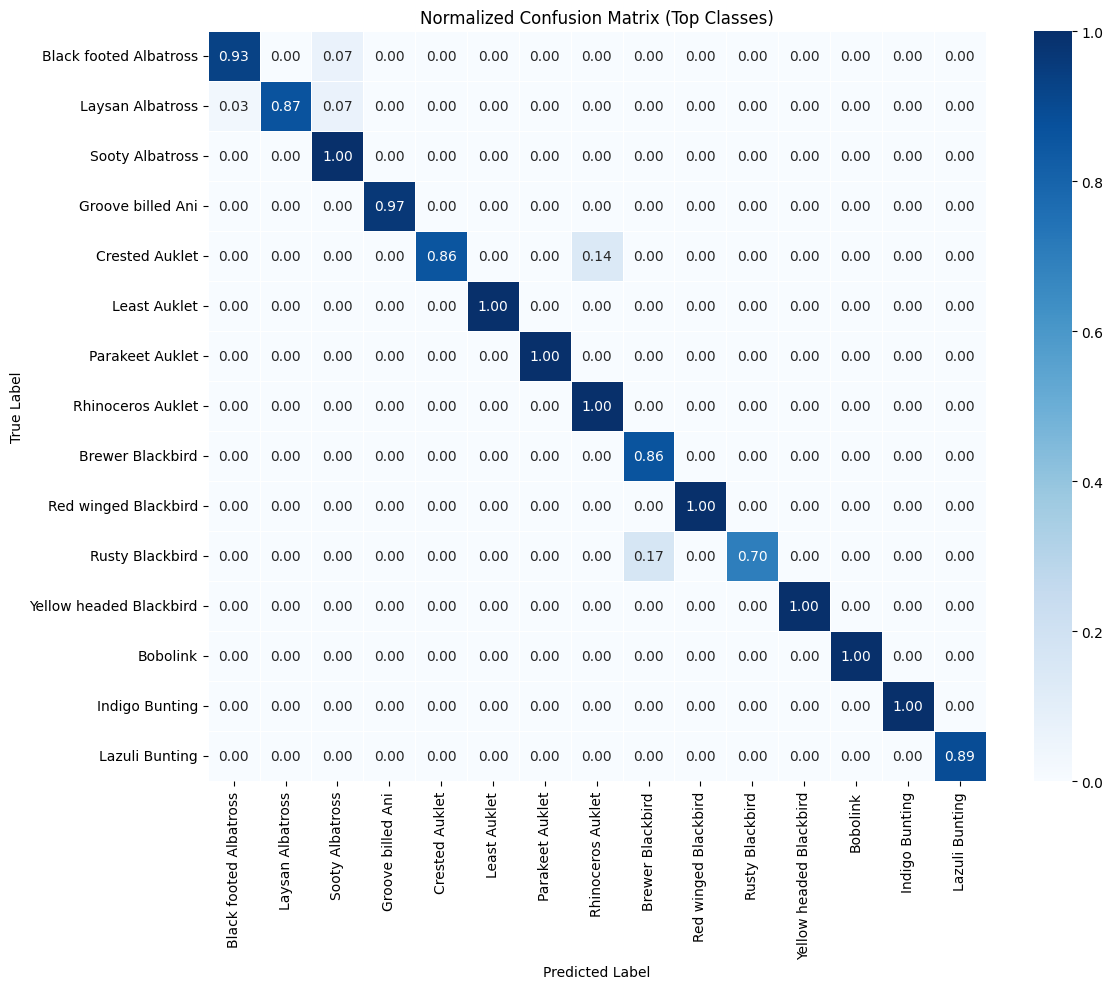

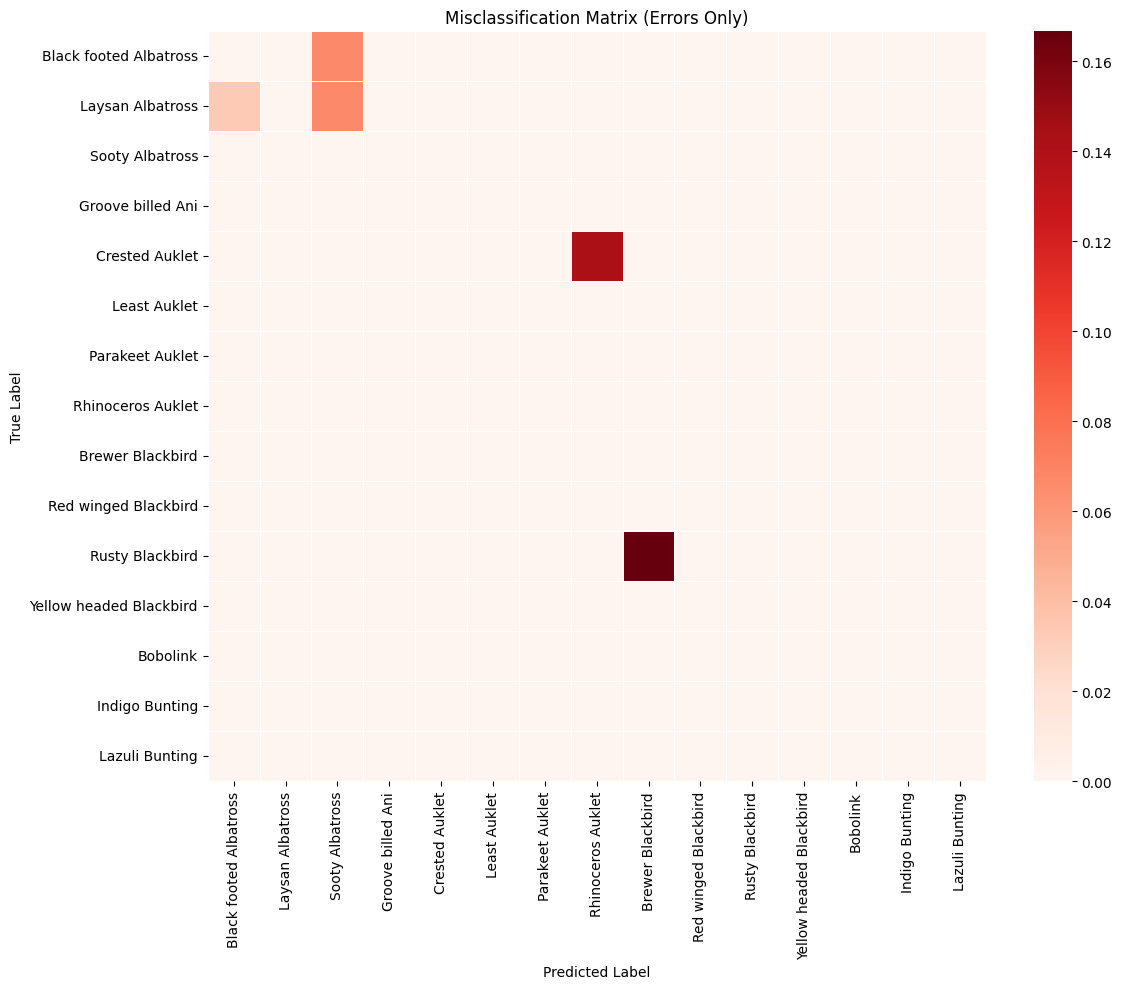


🔥 Top Confused Class Pairs:

Forsters Tern → Common Tern: 10 samples
Elegant Tern → Caspian Tern: 9 samples
Long tailed Jaeger → Pomarine Jaeger: 9 samples
California Gull → Western Gull: 9 samples
California Gull → Ring billed Gull: 9 samples
Fish Crow → American Crow: 9 samples
American Crow → Fish Crow: 9 samples
Common Tern → Forsters Tern: 8 samples
Common Tern → Artic Tern: 8 samples
Pelagic Cormorant → Red faced Cormorant: 8 samples


In [14]:
# =====================================
# 🔥 COMPLETE CONFUSION MATRIX ANALYSIS
# =====================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# =====================================
# 🔹 SAFETY CHECK
# =====================================
assert len(all_labels) == len(all_preds), "Mismatch in predictions and labels!"

# =====================================
# 🔹 COMPUTE CONFUSION MATRIX
# =====================================
cm = confusion_matrix(all_labels, all_preds)

# =====================================
# 🔥 NORMALIZED CONFUSION MATRIX
# =====================================
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# =====================================
# 🔹 SELECT TOP N CLASSES
# =====================================
TOP_N = 15   # reduce clutter (recommended 10–15)

cm_small = cm_norm[:TOP_N, :TOP_N]

class_names = clean_test_dataset.classes[:TOP_N]
class_names = [c.split(".")[-1].replace("_"," ") for c in class_names]

# =====================================
# 🔥 PLOT NORMALIZED CONFUSION MATRIX
# =====================================
plt.figure(figsize=(12,10))

sns.heatmap(
    cm_small,
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title("Normalized Confusion Matrix (Top Classes)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()


# =====================================
# 🔥 ERROR-ONLY CONFUSION MATRIX
# =====================================
cm_error = cm_small.copy()
np.fill_diagonal(cm_error, 0)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_error,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Reds",
    linewidths=0.5
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title("Misclassification Matrix (Errors Only)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()


# =====================================
# 🔥 TOP CONFUSED CLASS PAIRS
# =====================================
pairs = []

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i,j] > 0:
            pairs.append((cm[i,j], i, j))

pairs = sorted(pairs, reverse=True)[:10]

print("\n🔥 Top Confused Class Pairs:\n")

for val, i, j in pairs:
    true_class = clean_test_dataset.classes[i].split(".")[-1].replace("_"," ")
    pred_class = clean_test_dataset.classes[j].split(".")[-1].replace("_"," ")
    print(f"{true_class} → {pred_class}: {val} samples")

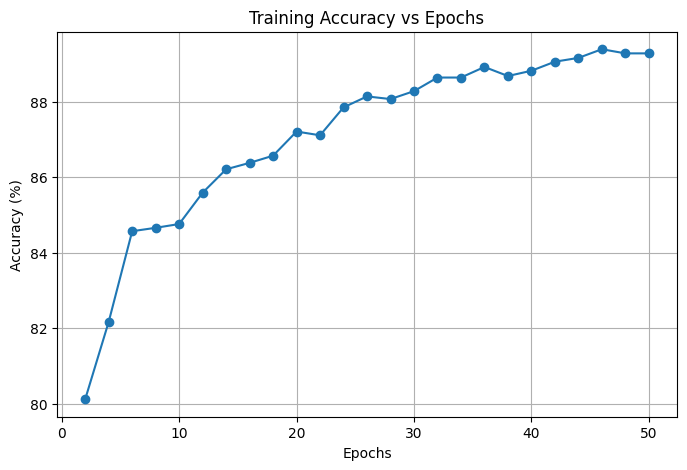

In [15]:
import matplotlib.pyplot as plt

epochs = list(range(2, 51, 2))
accuracy = [
    80.12, 82.17, 84.57, 84.66, 84.76,
    85.59, 86.21, 86.38, 86.57, 87.21,
    87.11, 87.85, 88.14, 88.07, 88.28,
    88.64, 88.64, 88.92, 88.68, 88.82,
    89.06, 89.16, 89.39, 89.28, 89.28
]

plt.figure(figsize=(8,5))
plt.plot(epochs, accuracy, marker='o')

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Epochs")

plt.grid()
plt.show()

In [ ]:
import numpy as np

np.save("preds.npy", all_preds)
np.save("labels.npy", all_labels)

In [ ]:
all_preds = np.load("preds.npy")
all_labels = np.load("labels.npy")